# 02 · Bibliometrics & Research Toolkit, Hands-On

Companion notebook to **Note 02 · Assignments Guide & Practical Research Toolkit** (Introduction to Research).

The note explains the *ideas* (h-index, impact factor, PRISMA, Boolean search, paraphrasing, references, planning); this notebook turns each one into a small, checkable computation.

| Part | What it does |
|---|---|
| 1 | h-index, i10-index and g-index calculators (with tests on the note's worked examples) |
| 2 | Citation distributions: rank plot and the long tail |
| 3 | Journal metrics: impact factor, CiteScore, quartiles; why one paper can move a JIF |
| 4 | PRISMA flow counts: a consistency checker |
| 5 | Evaluating a search query: precision and recall against a known set |
| 6 | Paraphrase vs copy: word 3-gram overlap |
| 7 | A literature-matrix template exported to CSV and Markdown |
| 8 | IEEE and APA reference formatter |
| 9 | Proposal planning: critical path and a Gantt chart |
| 10 | Optional: a Semantic Scholar query (offline-safe; off by default) |

Everything runs offline. No assignment answers are included: the data are toy examples or well-known published papers.

In [1]:
import re, json, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, MUTED = "#2a78d6", "#eb6834", "#52514e"

## Part 1 · h-index, i10-index, g-index

- **h-index** (Hirsch, 2005): the largest $h$ such that $h$ papers have at least $h$ citations each.
- **i10-index** (Google Scholar): number of papers with at least 10 citations.
- **g-index** (Egghe, 2006): the largest $g$ such that the top $g$ papers together have at least $g^2$ citations. Here $g$ is capped at the number of papers (some tools pad with zero-citation papers, which can give a larger $g$).

In [2]:
def h_index(cites):
    c = sorted(cites, reverse=True)
    return sum(1 for rank, x in enumerate(c, start=1) if x >= rank)

def i10_index(cites):
    return sum(1 for x in cites if x >= 10)

def g_index(cites):
    c = np.sort(np.asarray(cites))[::-1]
    cum = np.cumsum(c)
    ks = np.arange(1, len(c) + 1)
    ok = ks[cum >= ks**2]
    return int(ok.max()) if ok.size else 0

examples = {
    "A (worked example)": [48, 33, 25, 19, 12, 10, 9, 7, 4, 2, 1, 0],
    "B (one-hit wonder)": [100, 3, 2, 1, 1],
    "C (steady)": [6, 6, 6, 6, 6, 6],
    "P (practice)": [15, 15, 12, 11, 10, 10, 10, 9, 3],
    "Q (practice)": [0, 1, 4, 4, 5, 5, 8, 20, 31],
    "empty": [],
}
rows = [{"researcher": k, "papers": len(v), "total cites": sum(v),
         "h": h_index(v), "i10": i10_index(v), "g": g_index(v)} for k, v in examples.items()]
df = pd.DataFrame(rows); print(df.to_string(index=False))

assert h_index(examples["A (worked example)"]) == 7 and i10_index(examples["A (worked example)"]) == 6
assert h_index([]) == 0 and h_index([0, 0]) == 0 and h_index([1]) == 1
print("all tests passed")

        researcher  papers  total cites  h  i10  g
A (worked example)      12          170  7    6 12
B (one-hit wonder)       5          107  2    1  5
        C (steady)       6           36  6    0  6
      P (practice)       9           95  8    7  9
      Q (practice)       9           78  5    2  8
             empty       0            0  0    0  0
all tests passed


**Reading the table.** B has the most citations per paper but h = 2: the h-index rewards *consistent* impact and ignores how far the top paper exceeds h. C has h = 6 but i10 = 0. The g-index gives more credit to highly cited papers (B: g = 5).

## Part 2 · Citation distributions

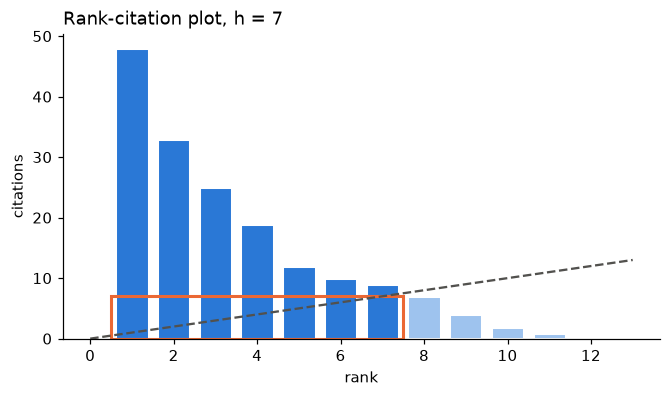

mean = 4.35, median = 2, max = 62
share of all citations earned by the top 10% of articles = 0.458
fraction of articles never cited = 0.198


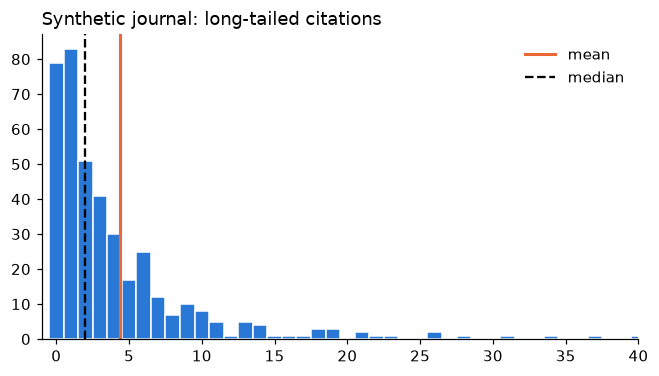

In [3]:
A = sorted(examples["A (worked example)"], reverse=True)
h = h_index(A); r = np.arange(1, len(A) + 1)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(r, A, color=[BLUE if i <= h else "#9ec3ee" for i in r], edgecolor="white", linewidth=2)
ax.plot([0, 13], [0, 13], ls="--", color=MUTED); ax.add_patch(plt.Rectangle((0.5, 0), h, h, fill=False, ec=ORANGE, lw=2))
ax.set_xlabel("rank"); ax.set_ylabel("citations"); ax.set_title(f"Rank-citation plot, h = {h}", loc="left"); plt.show()

rng = np.random.default_rng(2)
journal = np.floor(rng.lognormal(mean=1.0, sigma=1.1, size=400)).astype(int)
top = np.sort(journal)[::-1]
print(f"mean = {journal.mean():.2f}, median = {np.median(journal):.0f}, max = {journal.max()}")
print(f"share of all citations earned by the top 10% of articles = {top[:40].sum()/top.sum():.3f}")
print(f"fraction of articles never cited = {np.mean(journal == 0):.3f}")
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(journal, bins=np.arange(0, journal.max() + 2) - 0.5, color=BLUE, edgecolor="white")
ax.axvline(journal.mean(), color=ORANGE, lw=2, label="mean"); ax.axvline(np.median(journal), color="k", ls="--", label="median")
ax.set_xlim(-1, 40); ax.legend(frameon=False); ax.set_title("Synthetic journal: long-tailed citations", loc="left"); plt.show()

## Part 3 · Journal metrics

```
JIF(Y)       = citations in Y to items published in Y-1 and Y-2  /  citable items published in Y-1 and Y-2
CiteScore(Y) = citations in Y-3..Y to documents published in Y-3..Y  /  documents published in Y-3..Y
quartile     = Q1 if rank/N <= 0.25, Q2 if <= 0.5, Q3 if <= 0.75, else Q4   (within one subject category)
```

In [4]:
def jif(cites_to_prev2, citable_prev2):
    return sum(cites_to_prev2) / sum(citable_prev2)

def citescore(cites_4yr, docs_4yr):
    return cites_4yr / sum(docs_4yr)

def quartile(rank, n):
    p = rank / n
    return "Q1" if p <= 0.25 else "Q2" if p <= 0.5 else "Q3" if p <= 0.75 else "Q4"

print("JIF worked example     :", round(jif([610, 480], [120, 140]), 3))
print("CiteScore worked example:", round(citescore(3300, [150, 160, 170, 180]), 3))
print("JIF practice            :", round(jif([250, 190], [80, 95]), 3))
print("CiteScore practice      :", round(citescore(2100, [95, 110, 120, 125]), 3))
for rank, n in [(48, 210), (160, 210), (53, 210), (105, 210)]:
    print(f"rank {rank}/{n} -> percentile {rank/n:.3f} -> {quartile(rank, n)}")

# Sensitivity: one viral paper in a small journal
base = jif([300], [150])
viral = jif([300 + 900], [150])
print(f"\nsmall journal JIF without / with one paper cited 900 times: {base:.2f} -> {viral:.2f}")

JIF worked example     : 4.192
CiteScore worked example: 5.0
JIF practice            : 2.514
CiteScore practice      : 4.667
rank 48/210 -> percentile 0.229 -> Q1
rank 160/210 -> percentile 0.762 -> Q4
rank 53/210 -> percentile 0.252 -> Q2
rank 105/210 -> percentile 0.500 -> Q2

small journal JIF without / with one paper cited 900 times: 2.00 -> 8.00


## Part 4 · PRISMA 2020 flow counts

In [5]:
def prisma(db_records, other_records, duplicates, excluded_title_abstract, not_retrieved, excluded_full_text):
    identified = db_records + other_records
    screened = identified - duplicates
    sought = screened - excluded_title_abstract
    assessed = sought - not_retrieved
    included = assessed - sum(excluded_full_text.values())
    for name, v in [("screened", screened), ("sought", sought), ("assessed", assessed), ("included", included)]:
        assert v >= 0, f"negative count at {name}: check your numbers"
    return dict(identified=identified, screened=screened, sought=sought, assessed=assessed, included=included)

print(prisma(1240, 35, 310, 820, 6, {"wrong population": 41, "no evaluation on real data": 38, "not peer reviewed": 21, "duplicate study": 12}))

{'identified': 1275, 'screened': 965, 'sought': 145, 'assessed': 139, 'included': 27}


## Part 5 · Evaluating a search query

In [6]:
def search_quality(retrieved, relevant_known):
    retrieved, relevant_known = set(retrieved), set(relevant_known)
    hit = len(retrieved & relevant_known)
    p, r = hit / len(retrieved), hit / len(relevant_known)
    return dict(hits=hit, precision=round(p, 3), recall=round(r, 3), F1=round(2*p*r/(p+r), 3))

gold = range(40)                               # 40 papers an expert says are relevant
broad = list(range(30)) + list(range(1000, 1370))   # 400 results, 30 relevant
narrow = list(range(27)) + list(range(2000, 2063))  # 90 results, 27 relevant
print("broad query :", search_quality(broad, gold))
print("narrow query:", search_quality(narrow, gold))

broad query : {'hits': 30, 'precision': 0.075, 'recall': 0.75, 'F1': 0.136}
narrow query: {'hits': 27, 'precision': 0.3, 'recall': 0.675, 'F1': 0.415}


## Part 6 · Paraphrase vs copy: word 3-gram overlap

Similarity checkers (Turnitin, iThenticate, DrillBit used in Indian universities) match runs of words. A simple proxy: the share of the candidate's word 3-grams that also appear in the source (containment). A low score does **not** prove originality (ideas still need citations); a high score is a red flag.

In [7]:
def toks(s): return re.findall(r"[a-z0-9]+", s.lower())
def ngrams(t, n=3): return {tuple(t[i:i+n]) for i in range(len(t) - n + 1)}
def containment(src, cand, n=3):
    a, b = ngrams(toks(src), n), ngrams(toks(cand), n)
    return len(a & b) / len(b)

source = ("Residual connections let the gradient flow directly through many layers, which makes very deep "
          "networks much easier to optimise than plain stacks of layers.")
cands = {
    "A copy-edit": "Residual connections let the gradient flow directly through many layers, which makes very deep networks far easier to optimise than plain stacks.",
    "B synonym swap": "Skip connections allow the gradient to flow straight through many layers, making very deep networks much easier to optimise than plain layer stacks.",
    "C real paraphrase + cite": "Adding identity shortcuts gives the error signal a direct path backwards, so networks with over a hundred layers train well, whereas equally deep plain networks show higher training error [1].",
}
for k, v in cands.items():
    print(f"{k:26s} 3-gram containment = {containment(source, v):.3f}")

A copy-edit                3-gram containment = 0.850
B synonym swap             3-gram containment = 0.381
C real paraphrase + cite   3-gram containment = 0.000


## Part 7 · Literature-matrix template (CSV + Markdown)

In [8]:
cols = ["#", "Citation", "Venue/year", "Problem", "Method / key idea", "Data", "Main result (from abstract)",
        "Limitation / open question", "Relevance to me"]
matrix = pd.DataFrame([
    [1, "He et al.", "CVPR 2016", "Very deep nets are hard to optimise", "Residual (shortcut) learning",
     "ImageNet, CIFAR-10, COCO", "3.57% top-5 error (ensemble); ILSVRC 2015 1st place", "<your critique>", "<your notes>"],
    [2, "Vaswani et al.", "NeurIPS 2017", "Recurrence limits parallelism in seq2seq", "Attention only (Transformer)",
     "WMT 2014 En-De, En-Fr", "28.4 BLEU En-De; 41.8 BLEU En-Fr", "<your critique>", "<your notes>"],
    [3, "Devlin et al.", "NAACL 2019", "Unidirectional LMs limit fine-tuning", "Bidirectional masked-LM pre-training (BERT)",
     "BooksCorpus + English Wikipedia", "GLUE 80.5; SQuAD v1.1 F1 93.2", "<your critique>", "<your notes>"],
], columns=cols)
os.makedirs("outputs", exist_ok=True)
matrix.to_csv("outputs/02_literature_matrix.csv", index=False)
with open("outputs/02_literature_matrix.md", "w") as f:
    f.write(matrix.to_markdown(index=False))
print(matrix.to_markdown(index=False))

|   # | Citation       | Venue/year   | Problem                                  | Method / key idea                           | Data                            | Main result (from abstract)                         | Limitation / open question   | Relevance to me   |
|----:|:---------------|:-------------|:-----------------------------------------|:--------------------------------------------|:--------------------------------|:----------------------------------------------------|:-----------------------------|:------------------|
|   1 | He et al.      | CVPR 2016    | Very deep nets are hard to optimise      | Residual (shortcut) learning                | ImageNet, CIFAR-10, COCO        | 3.57% top-5 error (ensemble); ILSVRC 2015 1st place | <your critique>              | <your notes>      |
|   2 | Vaswani et al. | NeurIPS 2017 | Recurrence limits parallelism in seq2seq | Attention only (Transformer)                | WMT 2014 En-De, En-Fr           | 28.4 BLEU En-De; 41.8 BLEU En-Fr 

## Part 8 · IEEE and APA reference formatter

In [9]:
def initials(name):  # "Kaiming He" -> ("He", "K.")
    *given, last = name.split()
    return last, " ".join("-".join(part[0] + "." for part in g.split("-")) for g in given)  # Ming-Wei -> M.-W.

def ieee(p):
    a = [f"{ini} {last}" for last, ini in map(initials, p["authors"])]
    auth = a[0] + " et al." if len(a) > 6 else (", ".join(a[:-1]) + ", and " + a[-1] if len(a) > 2 else " and ".join(a))
    return f'{auth}, "{p["title"]}," in {p["venue_ieee"]}, {p["year"]}, pp. {p["pages"]}, doi: {p["doi"]}.'

def apa(p):
    a = [f"{last}, {ini}" for last, ini in map(initials, p["authors"])]
    auth = ", ".join(a[:-1]) + ", & " + a[-1] if len(a) > 1 else a[0]
    return f'{auth} ({p["year"]}). {p["title"]}. In {p["venue_apa"]} (pp. {p["pages"]}). https://doi.org/{p["doi"]}'

resnet = dict(authors=["Kaiming He", "Xiangyu Zhang", "Shaoqing Ren", "Jian Sun"],
              title="Deep residual learning for image recognition", year=2016, pages="770–778",
              venue_ieee="Proc. IEEE Conf. Comput. Vis. Pattern Recognit. (CVPR)",
              venue_apa="Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition",
              doi="10.1109/CVPR.2016.90")
bert = dict(authors=["Jacob Devlin", "Ming-Wei Chang", "Kenton Lee", "Kristina Toutanova"],
            title="BERT: Pre-training of deep bidirectional transformers for language understanding", year=2019,
            pages="4171–4186", venue_ieee="Proc. NAACL-HLT",
            venue_apa="Proceedings of the 2019 Conference of the North American Chapter of the Association for Computational Linguistics: Human Language Technologies",
            doi="10.18653/v1/N19-1423")
for p in (resnet, bert):
    print("[IEEE]", ieee(p)); print("[APA ]", apa(p)); print()

[IEEE] K. He, X. Zhang, S. Ren, and J. Sun, "Deep residual learning for image recognition," in Proc. IEEE Conf. Comput. Vis. Pattern Recognit. (CVPR), 2016, pp. 770–778, doi: 10.1109/CVPR.2016.90.
[APA ] He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. In Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (pp. 770–778). https://doi.org/10.1109/CVPR.2016.90

[IEEE] J. Devlin, M.-W. Chang, K. Lee, and K. Toutanova, "BERT: Pre-training of deep bidirectional transformers for language understanding," in Proc. NAACL-HLT, 2019, pp. 4171–4186, doi: 10.18653/v1/N19-1423.
[APA ] Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. In Proceedings of the 2019 Conference of the North American Chapter of the Association for Computational Linguistics: Human Language Technologies (pp. 4171–4186). https://doi.org/10.18653/v1/N19-1423



Always check the generated string against the DOI record (`https://doi.org/<doi>`) or the reference manager's output; never trust a formatter, human or AI, blindly.

## Part 9 · Proposal planning: critical path and Gantt

                          weeks  ES  EF  LS  LF  slack
A Literature search           3   0   3   0   3      0
B Deep reading + matrix       4   3   7   3   7      0
C Dataset setup               2   3   5   5   7      2
D Baseline experiments        5   7  12   7  12      0
E Proposed method             3  12  15  12  15      0
F Ethics / data approval      2   5   7  13  15      8
G Write-up                    2  15  17  15  17      0
project length = 17 weeks; critical path = A -> B -> D -> E -> G


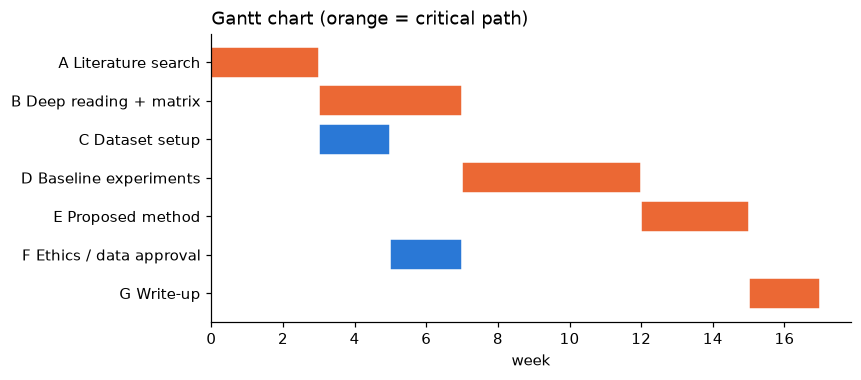

In [10]:
tasks = {  # name: (weeks, predecessors)
    "A Literature search": (3, []),
    "B Deep reading + matrix": (4, ["A Literature search"]),
    "C Dataset setup": (2, ["A Literature search"]),
    "D Baseline experiments": (5, ["B Deep reading + matrix", "C Dataset setup"]),
    "E Proposed method": (3, ["D Baseline experiments"]),
    "F Ethics / data approval": (2, ["C Dataset setup"]),
    "G Write-up": (2, ["E Proposed method", "F Ethics / data approval"]),
}
ES, EF = {}, {}
for t, (d, pre) in tasks.items():            # dict is already in topological order
    ES[t] = max([EF[p] for p in pre], default=0); EF[t] = ES[t] + d
T = max(EF.values())
LF, LS = {}, {}
for t in reversed(list(tasks)):
    succ = [s for s, (_, pre) in tasks.items() if t in pre]
    LF[t] = min([LS[s] for s in succ], default=T); LS[t] = LF[t] - tasks[t][0]
plan = pd.DataFrame({"weeks": {t: d for t, (d, _) in tasks.items()}, "ES": ES, "EF": EF, "LS": LS, "LF": LF})
plan["slack"] = plan.LS - plan.ES
print(plan.to_string()); print("project length =", T, "weeks; critical path =", " -> ".join(t[0] for t in tasks if plan.slack[t] == 0))

fig, ax = plt.subplots(figsize=(7.5, 3.4))
for i, t in enumerate(tasks):
    ax.barh(i, tasks[t][0], left=ES[t], color=ORANGE if plan.slack[t] == 0 else BLUE, edgecolor="white")
ax.set_yticks(range(len(tasks))); ax.set_yticklabels(list(tasks)); ax.invert_yaxis()
ax.set_xlabel("week"); ax.set_title("Gantt chart (orange = critical path)", loc="left"); plt.show()

## Part 10 · Optional: Semantic Scholar query (offline-safe)

Set `RUN_ONLINE = True` to query the public [Semantic Scholar Graph API](https://api.semanticscholar.org/api-docs/). It is off by default so the notebook runs anywhere; on any network error it falls back to a small cached sample, clearly labelled. Live citation counts change daily, so never copy them into a report without the access date.

In [11]:
RUN_ONLINE = False
QUERY = "speech emotion recognition low-resource"
cached = [{"title": "Deep residual learning for image recognition", "year": 2016, "venue": "CVPR", "source": "cached sample"},
          {"title": "Attention is all you need", "year": 2017, "venue": "NeurIPS", "source": "cached sample"}]

def s2_search(q, limit=5):
    import urllib.request, urllib.parse
    url = ("https://api.semanticscholar.org/graph/v1/paper/search?" +
           urllib.parse.urlencode({"query": q, "limit": limit, "fields": "title,year,venue,citationCount,externalIds"}))
    with urllib.request.urlopen(url, timeout=10) as r:
        return [dict(d, source="live") for d in json.load(r).get("data", [])]

try:
    results = s2_search(QUERY) if RUN_ONLINE else cached
except Exception as e:
    print("online query failed, using cached sample:", type(e).__name__)
    results = cached
print(pd.DataFrame(results).to_string(index=False))

                                       title  year   venue        source
Deep residual learning for image recognition  2016    CVPR cached sample
                   Attention is all you need  2017 NeurIPS cached sample
